In [185]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt


In [186]:
np.random.seed(42)
random.seed(42)

n_customers = 1000

customer_ids = [f"{str(i).zfill(4)}" for i in range(1001, 1001 + n_customers)]

segments = np.random.choice(
    ['Premium', 'Regular', 'Budget', 'Splurger'],
    size=n_customers,
    p=[0.20, 0.35, 0.30, 0.15]
)

platform = np.random.choice(
    ["Amazon", "Flipkart", "Snapdeal", "Meesho", "Myntra", "AJIO", "Nykaa", "Reliance Digital", "Croma"],
    size=n_customers
).tolist()

annual_spending = []
purchase_frequency = []
avg_transaction_value = []
product_categories_bought = []
customer_tenure_months = []
returns_count = []
online_purchase_ratio = []
loyalty_points_balance = []

for segment in segments:
    if segment == 'Premium':
        spending = np.random.normal(85000, 15000)
        frequency = np.random.normal(48, 8)
        avg_txn = spending / max(frequency, 1)
        
        tenure = np.random.randint(24, 84)
        returns = np.random.randint(0, 4)
        online_ratio = np.random.uniform(0.4, 0.8)
        loyalty = np.random.randint(2000, 8000)

    elif segment == 'Regular':
        spending = np.random.normal(35000, 8000)
        frequency = np.random.normal(24, 6)
        avg_txn = spending / max(frequency, 1)
       
        tenure = np.random.randint(12, 60)
        returns = np.random.randint(0, 6)
        online_ratio = np.random.uniform(0.3, 0.6)
        loyalty = np.random.randint(500, 2500)

    elif segment == 'Budget':
        spending = np.random.normal(1200, 400)
        frequency = np.random.normal(10, 4)
        avg_txn = spending / max(frequency, 1)
        tenure = np.random.randint(3, 36)
        returns = np.random.randint(0, 3)
        online_ratio = np.random.uniform(0.1, 0.4)
        loyalty = np.random.randint(50, 600)

    else:  # Splurger
        spending = np.random.normal(6000, 2000)
        frequency = np.random.normal(8, 3)
        avg_txn = spending / max(frequency, 1)
        tenure = np.random.randint(6, 48)
        returns = np.random.randint(0, 2)
        online_ratio = np.random.uniform(0.5, 0.9)
        loyalty = np.random.randint(800, 3500)

    annual_spending.append(max(100, round(spending, 2)))
    purchase_frequency.append(max(1, int(frequency)))
    avg_transaction_value.append(max(15, round(avg_txn, 2)))
    product_categories_bought.append(max(1, categories))
    customer_tenure_months.append(max(1, tenure))
    returns_count.append(max(0, returns))
    online_purchase_ratio.append(round(min(1, max(0, online_ratio)), 2))
    loyalty_points_balance.append(max(0, loyalty))

age = np.random.randint(18, 68, n_customers)
gender = np.random.choice(['Male', 'Female',], n_customers, p=[0.45, 0.55,])
region = np.random.choice(['North', 'South', 'East', 'West', 'Central'], n_customers, p=[0.22, 0.25, 0.18, 0.20, 0.15])

membership_type = []
for spending in annual_spending:
    if spending > 6000:
        membership_type.append(np.random.choice(['Gold', 'Platinum'], p=[0.4, 0.6]))
    elif spending > 3000:
        membership_type.append(np.random.choice(['Silver', 'Gold'], p=[0.6, 0.4]))
    else:
        membership_type.append(np.random.choice(['Bronze', 'Silver'], p=[0.7, 0.3]))

preferred_payment = np.random.choice(
    ['Credit Card', 'Debit Card', 'Digital Wallet', 'Cash', 'Buy Now Pay Later'],
    n_customers, p=[0.35, 0.25, 0.20, 0.12, 0.08]
)

df = pd.DataFrame({
    'Customer_ID': customer_ids,
    'Age': age,
    'Gender': gender,
    'Region': region,
    'Platform': platform,
    'Membership_Type': membership_type,
    'Annual_Spending': annual_spending,
    'Purchase_Frequency': purchase_frequency,
    'Returns_Count': returns_count,
    'Online_Purchase_Ratio': online_purchase_ratio,
    'Preferred_Payment_Method': preferred_payment,
    'Customer_Tenure_Months': customer_tenure_months
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.to_csv('customer_data.csv', index=False)

print("Dataset generated successfully!")
print(f"Shape: {df.shape}")
print(df.head(15))
print(df.describe())
print(df.dtypes)



Dataset generated successfully!
Shape: (1000, 12)
   Customer_ID  Age  Gender   Region  Platform Membership_Type  \
0         1522   28    Male  Central  Flipkart        Platinum   
1         1738   46  Female     West    Meesho          Bronze   
2         1741   46  Female     West      AJIO        Platinum   
3         1661   46  Female     West     Croma        Platinum   
4         1412   59    Male    South     Croma          Silver   
5         1679   44  Female    South      AJIO            Gold   
6         1627   45    Male    North  Flipkart            Gold   
7         1514   51    Male     West     Croma        Platinum   
8         1860   32    Male     West    Meesho        Platinum   
9         1137   34    Male     East  Flipkart            Gold   
10        1812   30    Male     East    Meesho          Bronze   
11        1077   23  Female    South     Croma          Bronze   
12        1637   36    Male    South     Croma        Platinum   
13        1974   28    Mal

In [187]:
df.isna().sum()

Customer_ID                 0
Age                         0
Gender                      0
Region                      0
Platform                    0
Membership_Type             0
Annual_Spending             0
Purchase_Frequency          0
Returns_Count               0
Online_Purchase_Ratio       0
Preferred_Payment_Method    0
Customer_Tenure_Months      0
dtype: int64

In [188]:
df1 = df.copy()

In [189]:
for col in df1.columns:
    df1.loc[df1.sample(frac=0.15).index, col] = np.nan

print(df1.isnull().sum())
df1.to_csv('customer_data.csv', index=False)


Customer_ID                 150
Age                         150
Gender                      150
Region                      150
Platform                    150
Membership_Type             150
Annual_Spending             150
Purchase_Frequency          150
Returns_Count               150
Online_Purchase_Ratio       150
Preferred_Payment_Method    150
Customer_Tenure_Months      150
dtype: int64


In [190]:
df1.dropna(subset=['Customer_ID'], inplace=True)
print("Rows after dropping missing Customer_ID:", len(df1))


Rows after dropping missing Customer_ID: 850


In [191]:
df1.shape

(850, 12)

In [203]:
median_cols = ['Age', 
               'Annual_Spending', 
               'Purchase_Frequency',
               'Returns_Count', 
               'Customer_Tenure_Months']

for col in median_cols:
    median_val = df1[col].median()
    df1[col]=df1[col].fillna(median_val)
    print(f"{col} filled with median: {median_val:.2f}")


Age filled with median: 42.00
Annual_Spending filled with median: 27838.90
Purchase_Frequency filled with median: 17.00
Returns_Count filled with median: 1.00
Customer_Tenure_Months filled with median: 31.00


In [207]:
mean_val = df1['Online_Purchase_Ratio'].mean()
df1['Online_Purchase_Ratio']=df1['Online_Purchase_Ratio'].fillna(mean_val)
print(f"Online_Purchase_Ratio filled with mean: {mean_val:.2f}")


Online_Purchase_Ratio filled with mean: 0.46


In [208]:
cat_cols = ['Gender', 
            'Region', 
            'Platform', 
            'Membership_Type',
            'Preferred_Payment_Method']

for col in cat_cols:
    mode_val = df1[col].mode()[0]
    df1[col] = df1[col].fillna(mode_val)
    print(f"{col} filled with mode: {mode_val}")
    


Gender filled with mode: Female
Region filled with mode: South
Platform filled with mode: Flipkart
Membership_Type filled with mode: Platinum
Preferred_Payment_Method filled with mode: Credit Card


In [210]:
print(df1.isnull().sum())

Customer_ID                 0
Age                         0
Gender                      0
Region                      0
Platform                    0
Membership_Type             0
Annual_Spending             0
Purchase_Frequency          0
Returns_Count               0
Online_Purchase_Ratio       0
Preferred_Payment_Method    0
Customer_Tenure_Months      0
dtype: int64


In [211]:
df1["Gender"]=df1["Gender"].map({"Male":0,"Female":1})
df1["Region"]=df1["Region"].map({"East":0,"West":1,"North":2,"South":3,"Central":4})
df1["Platform"] = df1["Platform"].map({
    "Amazon": 0, "Flipkart": 1, "Snapdeal": 2,
    "Meesho": 3, "Myntra": 4, "AJIO": 5,
    "Nykaa": 6, "Reliance Digital": 7, "Croma": 8
})

df1["Membership_Type"] = df1["Membership_Type"].map({
    "Bronze": 0, "Silver": 1, "Gold": 2, "Platinum": 3
})

df1["Preferred_Payment_Method"] = df1["Preferred_Payment_Method"].map({
    "Credit Card": 0, "Debit Card": 1,
    "Digital Wallet": 2, "Cash": 3,
    "Buy Now Pay Later": 4
})

In [213]:
df1

,Customer_ID,Age,Gender,Region,Platform,Membership_Type,Annual_Spending,Purchase_Frequency,Returns_Count,Online_Purchase_Ratio,Preferred_Payment_Method,Customer_Tenure_Months
0,1522,28.0,0,4,1,3,43444.30,24.0,3.0,0.53,3,56.0
1,1738,46.0,1,1,1,3,27838.90,10.0,2.0,0.15,0,18.0
2,1741,46.0,1,1,1,3,30250.27,30.0,1.0,0.55,2,29.0
3,1661,46.0,1,1,8,3,38433.06,19.0,2.0,0.32,0,24.0
4,1412,42.0,0,3,8,1,5999.76,11.0,0.0,0.75,3,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1107,50.0,1,2,5,3,30243.15,11.0,5.0,0.54,0,31.0
996,1271,62.0,0,1,5,0,1497.55,12.0,1.0,0.38,2,29.0
997,1861,50.0,0,1,1,1,1648.34,7.0,0.0,0.27,3,4.0
998,1436,46.0,0,1,4,0,27838.90,8.0,1.0,0.29,0,31.0


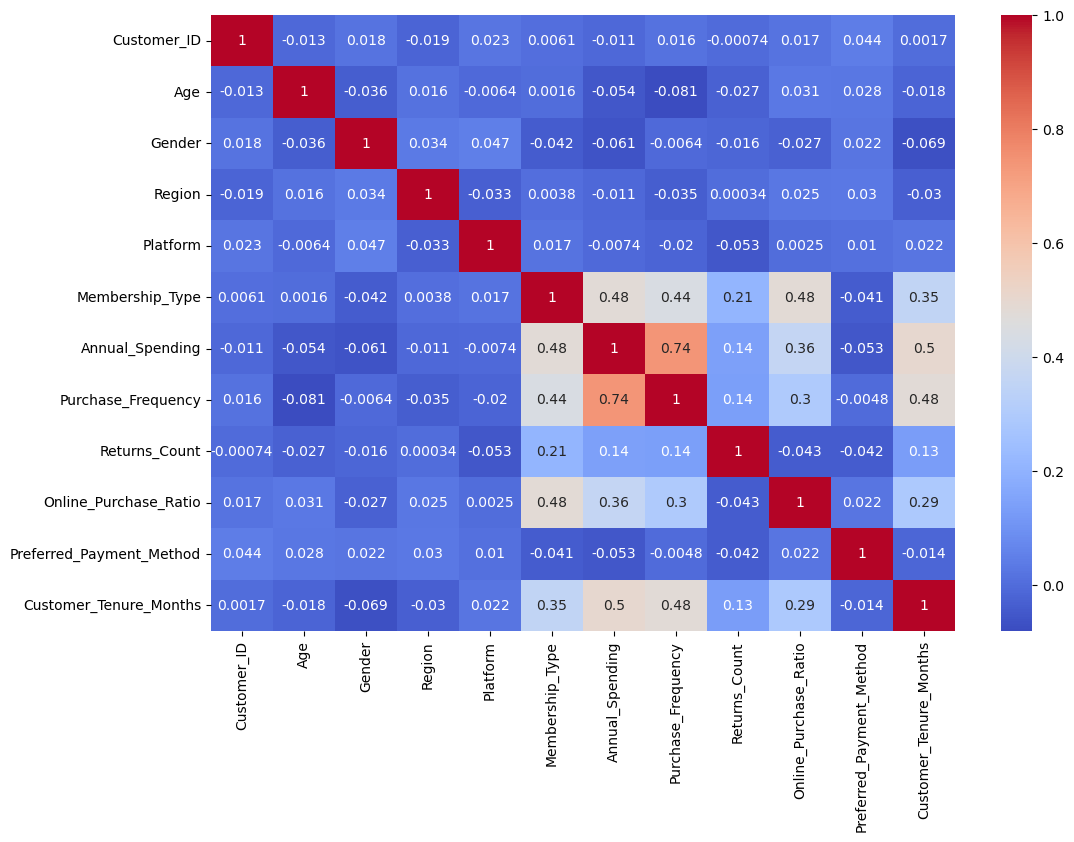

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
corr = df1.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [215]:
corr_matrix = df1.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [column for column in upper.columns 
             if any(upper[column] > 0.85)]

print("Highly correlated features to drop:", high_corr)

Highly correlated features to drop: []


In [216]:
corr_matrix = df1.corr().abs()

print(corr_matrix['Purchase_Frequency'].sort_values(ascending=False))

Purchase_Frequency          1.000000
Annual_Spending             0.740381
Customer_Tenure_Months      0.476655
Membership_Type             0.438512
Online_Purchase_Ratio       0.296544
Returns_Count               0.135664
Age                         0.080865
Region                      0.034951
Platform                    0.020170
Customer_ID                 0.016181
Gender                      0.006372
Preferred_Payment_Method    0.004837
Name: Purchase_Frequency, dtype: float64


In [232]:

df2 = df1.drop(columns=[
    'Customer_ID',              
    'Platform',                
    'Age',                     
    'Region',                   
    'Gender',                  
    'Preferred_Payment_Method'
           
])

In [233]:
df2

,Membership_Type,Annual_Spending,Purchase_Frequency,Returns_Count,Online_Purchase_Ratio,Customer_Tenure_Months
0,3,43444.30,24.0,3.0,0.53,56.0
1,3,27838.90,10.0,2.0,0.15,18.0
2,3,30250.27,30.0,1.0,0.55,29.0
3,3,38433.06,19.0,2.0,0.32,24.0
4,1,5999.76,11.0,0.0,0.75,31.0
...,...,...,...,...,...,...
995,3,30243.15,11.0,5.0,0.54,31.0
996,0,1497.55,12.0,1.0,0.38,29.0
997,1,1648.34,7.0,0.0,0.27,4.0
998,0,27838.90,8.0,1.0,0.29,31.0
